#  EV Charging Baselines

This notebook builds simple charging baselines.

## Purpose

Create two simple baselines before optimisation:

1. Charge immediately after arrival.
2. Delay charging toward 11:00 when it is still feasible.

Both methods respect connection times, charger power and the site power limit.

In [1]:
from pathlib import Path
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either the root or Notebooks directory."""
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "Data").exists() and (candidate / "Notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing Data/ and Notebooks/.")


ROOT = find_project_root()
DATA_DIR = ROOT / "Data"
RESULTS_DIR = DATA_DIR / "Results"
PROCESSED_DIR = DATA_DIR / "Processed"
FIGURES_DIR = ROOT / "Figures"
MODELS_DIR = ROOT / "Models" / "Forecasting"

for directory in [RESULTS_DIR, PROCESSED_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INTERVAL_MINUTES = 5
INTERVAL_HOURS = INTERVAL_MINUTES / 60
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"Project root: {ROOT}")

Project root: /Users/mac/Send-Ev-Project/SEND-EV-Project


In [2]:
def save_table(df: pd.DataFrame, path: Path) -> Path:
    """Save Parquet where available, otherwise save CSV with the same stem."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix.lower() == ".parquet":
        try:
            df.to_parquet(path, index=False)
            print(f"Saved: {path.relative_to(ROOT)}")
            return path
        except (ImportError, ModuleNotFoundError) as exc:
            csv_path = path.with_suffix(".csv")
            df.to_csv(csv_path, index=False)
            print(f"Parquet engine unavailable ({exc.__class__.__name__}); saved CSV: {csv_path.relative_to(ROOT)}")
            return csv_path
    df.to_csv(path, index=False)
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def read_table(path: Path, parse_dates: list[str] | None = None) -> pd.DataFrame:
    """Read a Parquet/CSV output regardless of which format was written."""
    candidates = [path]
    if path.suffix.lower() == ".parquet":
        candidates.append(path.with_suffix(".csv"))
    elif path.suffix.lower() == ".csv":
        candidates.append(path.with_suffix(".parquet"))

    for candidate in candidates:
        if candidate.exists():
            if candidate.suffix.lower() == ".parquet":
                return pd.read_parquet(candidate)
            return pd.read_csv(candidate, parse_dates=parse_dates)
    raise FileNotFoundError(f"None of these files exists: {candidates}")

In [3]:
scenarios = read_table(DATA_DIR / "ACN" / "processed" / "keele_ev_scenarios.parquet")
send = read_table(PROCESSED_DIR / "send_solcast_surplus_5min.parquet", parse_dates=["DateTime"])

for column in ["arrival_time", "departure_time", "keele_date"]:
    scenarios[column] = pd.to_datetime(scenarios[column], errors="coerce")
send["DateTime"] = pd.to_datetime(send["DateTime"], errors="coerce")

print(f"Scenarios: {scenarios['scenario_id'].nunique():,}")

Scenarios: 1,280


In [4]:
def scenario_time_grid(group: pd.DataFrame, send: pd.DataFrame) -> pd.DatetimeIndex:
    start = pd.Timestamp(group["keele_date"].iloc[0]).normalize()
    latest_departure = pd.to_datetime(group["departure_time"]).max()
    # Use at most 48 hours of SEND data.
    end = min(latest_departure.ceil(f"{INTERVAL_MINUTES}min"), start + pd.Timedelta(hours=48))
    available_end = send["DateTime"].max() + pd.Timedelta(minutes=INTERVAL_MINUTES)
    end = min(end, available_end)
    return pd.date_range(start, end, freq=f"{INTERVAL_MINUTES}min", inclusive="left")


def aligned_send_series(send: pd.DataFrame, grid: pd.DatetimeIndex, column: str) -> np.ndarray:
    series = send.set_index("DateTime")[column].reindex(grid)
    # Fill short gaps; set any remaining gaps to zero.
    return series.interpolate(limit=3).fillna(0).to_numpy(dtype=float)


def schedule_metrics(
    scenario: pd.DataFrame,
    vehicle_schedule: pd.DataFrame,
    send: pd.DataFrame,
    strategy: str,
    forecast_source: str = "none",
) -> dict:
    grid = scenario_time_grid(scenario, send)
    surplus = aligned_send_series(send, grid, "surplus_kw")
    consumption = aligned_send_series(send, grid, "consumption_kw")

    if vehicle_schedule.empty:
        aggregate = pd.Series(0.0, index=grid)
        delivered_by_vehicle = pd.Series(dtype=float)
    else:
        schedule = vehicle_schedule.copy()
        schedule["DateTime"] = pd.to_datetime(schedule["DateTime"])
        aggregate = schedule.groupby("DateTime")["charging_kw"].sum().reindex(grid, fill_value=0.0)
        delivered_by_vehicle = (
            schedule.groupby("vehicle_id")["charging_kw"].sum() * INTERVAL_HOURS
        )

    required = scenario.set_index("vehicle_id")["energy_required_kwh"]
    delivered = delivered_by_vehicle.reindex(required.index, fill_value=0.0)
    service_rate = float((delivered >= required * 0.99).mean())
    unserved = float((required - delivered).clip(lower=0).sum())

    renewable_absorbed = np.minimum(aggregate.to_numpy(), surplus).sum() * INTERVAL_HOURS
    residual_surplus = np.maximum(surplus - aggregate.to_numpy(), 0).sum() * INTERVAL_HOURS
    ev_grid_energy = np.maximum(aggregate.to_numpy() - surplus, 0).sum() * INTERVAL_HOURS

    return {
        "scenario_id": scenario["scenario_id"].iloc[0],
        "keele_date": scenario["keele_date"].iloc[0],
        "scenario_site": scenario["scenario_site"].iloc[0],
        "fleet_size": int(scenario["fleet_size"].iloc[0]),
        "participation_rate": float(scenario["participation_rate"].iloc[0]),
        "participant_count": int(scenario["participant_count"].iloc[0]),
        "site_limit_kw": float(scenario["site_limit_kw"].iloc[0]),
        "strategy": strategy,
        "forecast_source": forecast_source,
        "required_energy_kwh": float(required.sum()),
        "delivered_energy_kwh": float(delivered.sum()),
        "unserved_energy_kwh": unserved,
        "service_rate": service_rate,
        "renewable_absorbed_kwh": float(renewable_absorbed),
        "residual_surplus_kwh": float(residual_surplus),
        "ev_grid_energy_kwh": float(ev_grid_energy),
        "peak_ev_kw": float(aggregate.max()),
        "peak_total_load_kw": float((aggregate.to_numpy() + consumption).max()),
    }

## 1. Greedy baseline scheduler

In [5]:
def greedy_schedule(
    scenario: pd.DataFrame,
    send: pd.DataFrame,
    strategy: str,
    fixed_start_hour: int = 11,
) -> pd.DataFrame:
    group = scenario.copy().sort_values(["departure_time", "arrival_time"]).reset_index(drop=True)
    grid = scenario_time_grid(group, send)
    site_limit_kw = float(group["site_limit_kw"].iloc[0])

    remaining = group.set_index("vehicle_id")["energy_required_kwh"].astype(float).to_dict()
    records = []

    if strategy == "immediate":
        group["eligible_start"] = group["arrival_time"]
    elif strategy == "fixed_delayed":
        target = pd.Timestamp(group["keele_date"].iloc[0]).normalize() + pd.Timedelta(hours=fixed_start_hour)
        latest_feasible = group["departure_time"] - pd.to_timedelta(
            group["energy_required_kwh"] / (group["max_power_kw"] * group["efficiency"]), unit="h"
        )
        group["eligible_start"] = np.maximum(
            group["arrival_time"].to_numpy(dtype="datetime64[ns]"),
            np.minimum(np.datetime64(target), latest_feasible.to_numpy(dtype="datetime64[ns]")),
        )
        group["eligible_start"] = pd.to_datetime(group["eligible_start"])
    else:
        raise ValueError(f"Unknown baseline strategy: {strategy}")

    for timestamp in grid:
        available_site_power = site_limit_kw
        eligible = group[
            group["arrival_time"].le(timestamp)
            & group["departure_time"].gt(timestamp)
            & group["eligible_start"].le(timestamp)
        ].sort_values(["departure_time", "arrival_time"])

        for _, vehicle in eligible.iterrows():
            vehicle_id = vehicle["vehicle_id"]
            if remaining[vehicle_id] <= 1e-9 or available_site_power <= 1e-9:
                continue
            power_needed = remaining[vehicle_id] / (INTERVAL_HOURS * vehicle["efficiency"])
            charging_kw = min(float(vehicle["max_power_kw"]), available_site_power, power_needed)
            if charging_kw <= 0:
                continue
            remaining[vehicle_id] -= charging_kw * INTERVAL_HOURS * float(vehicle["efficiency"])
            available_site_power -= charging_kw
            records.append({
                "scenario_id": vehicle["scenario_id"],
                "vehicle_id": vehicle_id,
                "DateTime": timestamp,
                "charging_kw": charging_kw,
                "strategy": strategy,
                "forecast_source": "none",
            })

    return pd.DataFrame(records)

## 2. Run baseline experiments

In [6]:
# Use a number for a quick run. Use None for all scenarios.
MAX_SCENARIOS = 24
scenario_ids = scenarios["scenario_id"].drop_duplicates().tolist()
if MAX_SCENARIOS is not None:
    scenario_ids = scenario_ids[:MAX_SCENARIOS]

schedule_frames = []
metric_rows = []
for count, scenario_id in enumerate(scenario_ids, start=1):
    scenario = scenarios[scenarios["scenario_id"].eq(scenario_id)].copy()
    for strategy in ["immediate", "fixed_delayed"]:
        schedule = greedy_schedule(scenario, send, strategy)
        schedule_frames.append(schedule)
        metric_rows.append(schedule_metrics(scenario, schedule, send, strategy))
    if count % 25 == 0 or count == len(scenario_ids):
        print(f"Completed {count}/{len(scenario_ids)} scenarios")

baseline_schedule = pd.concat(schedule_frames, ignore_index=True) if schedule_frames else pd.DataFrame()
baseline_metrics = pd.DataFrame(metric_rows)
display(baseline_metrics.groupby("strategy")[[
    "service_rate", "renewable_absorbed_kwh", "residual_surplus_kwh", "ev_grid_energy_kwh"
]].mean())

Completed 24/24 scenarios


,service_rate,renewable_absorbed_kwh,residual_surplus_kwh,ev_grid_energy_kwh
strategy,,,,
fixed_delayed,0.981433,159.460127,12536.144298,35.096308
immediate,1.000000,136.034664,12559.569761,58.702975


## 3. Save outputs

In [7]:
save_table(baseline_schedule, RESULTS_DIR / "baseline_vehicle_schedule.parquet")
save_table(baseline_metrics, RESULTS_DIR / "baseline_metrics.csv")

Parquet engine unavailable (ImportError); saved CSV: Data/Results/baseline_vehicle_schedule.csv
Saved: Data/Results/baseline_metrics.csv


PosixPath('/Users/mac/Send-Ev-Project/SEND-EV-Project/Data/Results/baseline_metrics.csv')

## 4. Plot one scenario

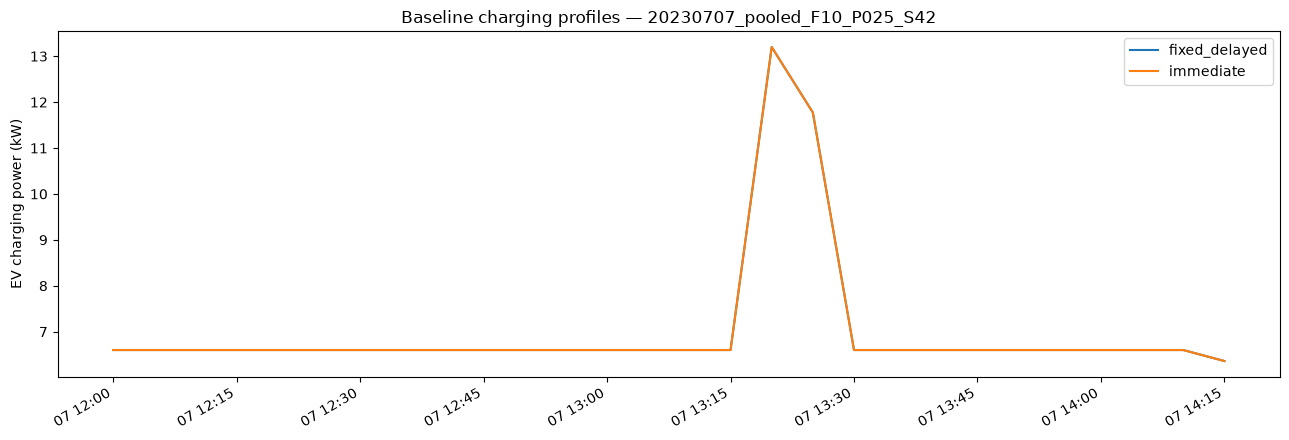

In [8]:
if not baseline_schedule.empty:
    example_id = baseline_schedule["scenario_id"].iloc[0]
    example = baseline_schedule[baseline_schedule["scenario_id"].eq(example_id)]
    aggregate = example.groupby(["strategy", "DateTime"], as_index=False)["charging_kw"].sum()

    fig, ax = plt.subplots(figsize=(13, 4.5))
    for strategy, frame in aggregate.groupby("strategy"):
        ax.plot(frame["DateTime"], frame["charging_kw"], label=strategy)
    ax.set_title(f"Baseline charging profiles — {example_id}")
    ax.set_ylabel("EV charging power (kW)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "baseline_charging_profile.png", dpi=200, bbox_inches="tight")
    plt.show()